# Decision Trees

**Author:** Saksham Chauhan

**Education**
- B.Sc. (Hons.) Statistics, University of Delhi
- M.Sc. Statistics, University of Delhi
- M.Tech. Artificial Intelligence & Data Science, IIIT Kottayam

**Connect**
- LinkedIn: https://linkedin.com/in/sakshamstats
- GitHub: https://github.com/sakshamchauhan-stats

# 1. Introduction

Decision Trees are non-parametric supervised machine learning algorithms used for both classification and regression. The algorithm recursively partitions the feature space into smaller and more homogeneous regions by selecting the best feature and split point at each node.

The resulting model resembles an inverted tree, where each internal node represents a decision based on a feature, each branch represents the outcome of that decision, and each leaf node represents the final prediction.


### Intuition

The fundamental idea behind Decision Trees is to repeatedly ask simple questions that divide the dataset into increasingly homogeneous groups.

For example, suppose we want to predict whether a customer will purchase a product.

```
Age > 30?
        │
   Yes      No
    │         │
Income > 50K? Student?
    │           │
   Yes         Yes
    │           │
 Purchase    Purchase
```

Each question reduces the uncertainty in the data until the observations in each leaf node become sufficiently similar.

### Algorithm Family

- Supervised
- Non-Parametric
- Eager Learner
- Deterministic
- Discriminative
- Batch Leaner



---

## Mathematical Idea

The objective of a Decision Tree is to select the split that produces the purest child nodes.

For Classification, impurity is commonly measured using

- Gini Impurity
- Entropy (Information Gain)
- Log Loss (supported in Scikit-learn)

For Regression, impurity is measured using

- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Friedman MSE
- Poisson Deviance

At each node, the algorithm evaluates all possible splits and selects the one that maximizes impurity reduction.

---

### Tree Components

#### Root Node

The first node of the tree representing the entire dataset.

#### Decision Node

An internal node where a feature is used to split the data.

#### Leaf Node

The terminal node that contains the final prediction.

- Majority class (Classification)
- Mean target value (Regression)

#### Branch

A connection between two nodes representing the outcome of a decision.

---

### Algorithm

1. Begin with the complete training dataset.
2. Evaluate every possible split for every feature.
3. Select the split that produces the greatest impurity reduction.
4. Partition the data into child nodes.
5. Repeat the process recursively.
6. Stop when a stopping criterion is satisfied.
7. Assign a prediction to each leaf node.

### When Do Decision Trees Perform Well?

Decision Trees generally perform well when

- Relationships between features and target are non-linear.
- Features interact with one another.
- Numerical and categorical variables are both present.
- Interpretability is important.

### When Should Decision Trees be Avoided?

Decision Trees may perform poorly when

- The dataset is very noisy.
- Small changes in the data lead to large changes in the tree.


### Key Takeaways

- Decision Trees recursively partition the feature space into homogeneous regions.
- They support both classification and regression.
- They naturally model non-linear relationships and feature interactions.
- They require little preprocessing compared to many other algorithms.
- Individual Decision Trees are easy to interpret but are prone to overfitting.

# 2. Scikit-Learn Implementation

### Classification Dataset
The Bank Marketing dataset contains customer demographic and campaign-related information collected by a Portuguese banking institution. The objective is to predict whether a customer will subscribe to a term deposit based on previous marketing interactions.
### Regression Dataset
The House Prices dataset contains various structural and neighbourhood characteristics of residential properties. The objective is to predict the selling price of a house based on its physical and location-related features.

In [16]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    KFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)

from sklearn.metrics import (
    classification_report,
    mean_absolute_error,
    mean_squared_error,
)

### Classification Model

In [17]:
# Download the dataset
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

# Load the dataset
df = pd.read_csv(f"{path}/bank.csv")
print(df.head())

# Separate features and target
X = df.drop(columns="deposit")
y = df["deposit"]

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [18]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(exclude="object").columns
categorical_features = X.select_dtypes(include="object").columns

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Create the pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

In [19]:
# Hyperparameter search space
param_grid = {

    "model__criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "model__splitter": [
        "best",
        "random"
    ],

    "model__max_depth": np.arange(2, 11),

    "model__min_samples_split": np.arange(2, 15),

    "model__min_samples_leaf": np.arange(1, 11),

    "model__max_features": [
        None,
        "sqrt",
        "log2"
    ],

    "model__max_leaf_nodes": [
        None,
        20,
        50,
        100
    ],

    "model__ccp_alpha": np.linspace(0, 0.05, 10)
}

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter tuning
decision_tree_classifier_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=25,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Train the model
decision_tree_classifier_search.fit(X_train, y_train)

# Generate predictions
y_pred = decision_tree_classifier_search.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred))

# Best hyperparameters
print("\nBest Hyperparameters\n")
print(decision_tree_classifier_search.best_params_)

# Tree information
tree = decision_tree_classifier_search.best_estimator_.named_steps["model"]

print("\nTree Statistics")
print(f"Maximum Depth : {tree.tree_.max_depth}")
print(f"Number of Nodes : {tree.tree_.node_count}")
print(f"Number of Leaves : {tree.get_n_leaves()}")

              precision    recall  f1-score   support

          no       0.83      0.80      0.81      1175
         yes       0.79      0.81      0.80      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233


Best Hyperparameters

{'model__splitter': 'best', 'model__min_samples_split': np.int64(11), 'model__min_samples_leaf': np.int64(1), 'model__max_leaf_nodes': 20, 'model__max_features': None, 'model__max_depth': np.int64(5), 'model__criterion': 'entropy', 'model__ccp_alpha': np.float64(0.005555555555555556)}

Tree Statistics
Maximum Depth : 5
Number of Nodes : 19
Number of Leaves : 10


,Feature,Importance
3,num__duration,0.600485
49,cat__poutcome_success,0.176890
34,cat__contact_unknown,0.162548
28,cat__housing_no,0.035622
42,cat__month_mar,0.024455
5,num__pdays,0.000000
6,num__previous,0.000000
2,num__day,0.000000
4,num__campaign,0.000000
9,cat__job_entrepreneur,0.000000


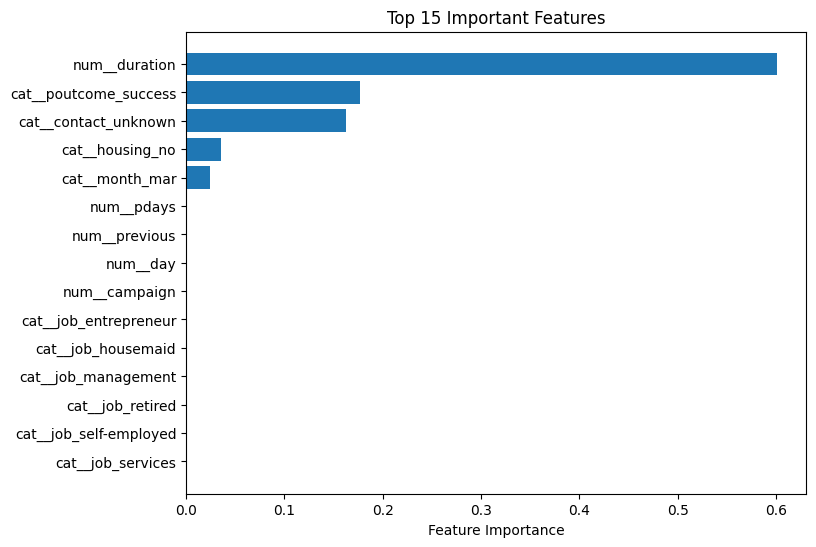

In [20]:
# Feature importance
feature_importance = pd.DataFrame({
    "Feature": decision_tree_classifier_search
        .best_estimator_
        .named_steps["preprocessor"]
        .get_feature_names_out(),

    "Importance": tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

# Plot feature importance
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"][:15][::-1],
    feature_importance["Importance"][:15][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 15 Important Features")

plt.show()


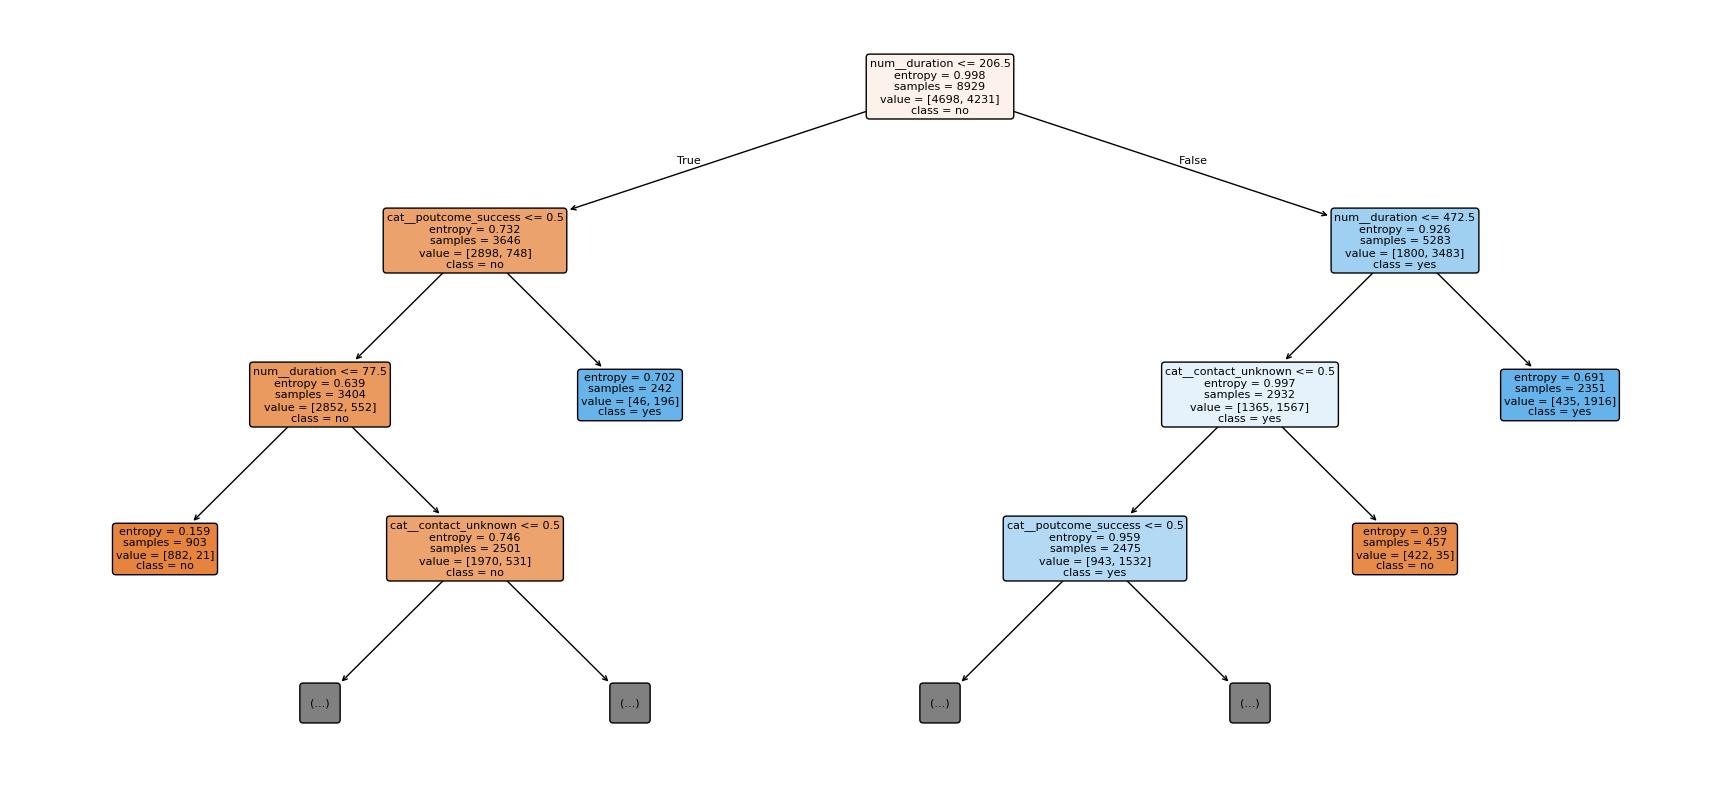

In [21]:
# Visualize the tree
plt.figure(figsize=(22,10))

plot_tree(
    tree,
    feature_names=decision_tree_classifier_search
        .best_estimator_
        .named_steps["preprocessor"]
        .get_feature_names_out(),
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.show()

### Regression Model

In [22]:
# Download the dataset
path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

# Load the dataset
df = pd.read_csv(f"{path}/AmesHousing.csv")
df.head()

# Separate features and target
X = df.drop(columns="SalePrice")
y = df["SalePrice"]

In [23]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(exclude="object").columns
categorical_features = X.select_dtypes(include="object").columns

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
# Create the pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

# Hyperparameter search space
param_grid = {

    "model__criterion": [
        "squared_error",
        "friedman_mse",
        "absolute_error",
        "poisson"
    ],

    "model__splitter": [
        "best",
        "random"
    ],

    "model__max_depth": np.arange(2, 31),

    "model__min_samples_split": np.arange(2, 21),

    "model__min_samples_leaf": np.arange(1, 11),

    "model__max_features": [
        None,
        "sqrt",
        "log2"
    ],

    "model__max_leaf_nodes": [
        None,
        20,
        50,
        100
    ],

    "model__ccp_alpha": np.linspace(0, 0.02, 20)
}

# Define the cross-validation strategy
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter tuning
decision_tree_regressor_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Train the model
decision_tree_regressor_search.fit(X_train, y_train)

# Generate predictions
y_pred = decision_tree_regressor_search.predict(X_test)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Display evaluation metrics
print(f"MAE          : {mae:.2f}")
print(f"RMSE         : {rmse:.2f}")

# Display best hyperparameters
print("\nBest Hyperparameters\n")
print(decision_tree_regressor_search.best_params_)

# Extract the trained tree
tree = decision_tree_regressor_search.best_estimator_.named_steps["model"]

# Display tree statistics
print("\nTree Statistics")
print(f"Maximum Depth : {tree.tree_.max_depth}")
print(f"Number of Nodes : {tree.tree_.node_count}")
print(f"Number of Leaves : {tree.get_n_leaves()}")

MAE          : 25807.93
RMSE         : 41094.60

Best Hyperparameters

{'model__splitter': 'random', 'model__min_samples_split': np.int64(8), 'model__min_samples_leaf': np.int64(8), 'model__max_leaf_nodes': 100, 'model__max_features': None, 'model__max_depth': np.int64(11), 'model__criterion': 'friedman_mse', 'model__ccp_alpha': np.float64(0.01894736842105263)}

Tree Statistics
Maximum Depth : 11
Number of Nodes : 199
Number of Leaves : 100


,Feature,Importance
179,cat__Exter Qual_TA,0.389384
191,cat__Bsmt Qual_Ex,0.178957
27,num__Garage Cars,0.082668
17,num__Gr Liv Area,0.077165
25,num__Fireplaces,0.048675
...,...,...
31,num__Enclosed Porch,0.000000
26,num__Garage Yr Blt,0.000000
32,num__3Ssn Porch,0.000000
33,num__Screen Porch,0.000000


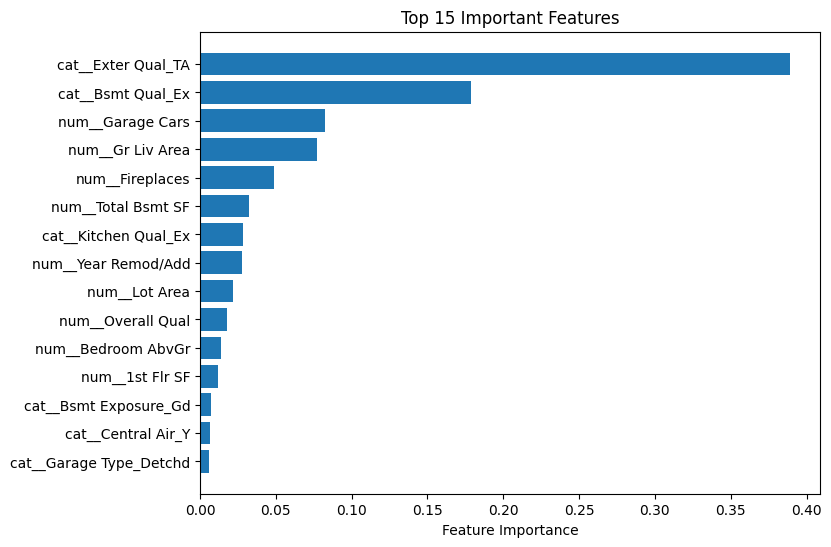

In [25]:
# Compute feature importance
feature_importance = pd.DataFrame({
    "Feature": (
        decision_tree_regressor_search
        .best_estimator_
        .named_steps["preprocessor"]
        .get_feature_names_out()
    ),
    "Importance": tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
display(feature_importance)

# Plot the top 15 important features
plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["Feature"][:15][::-1],
    feature_importance["Importance"][:15][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 15 Important Features")

plt.show()

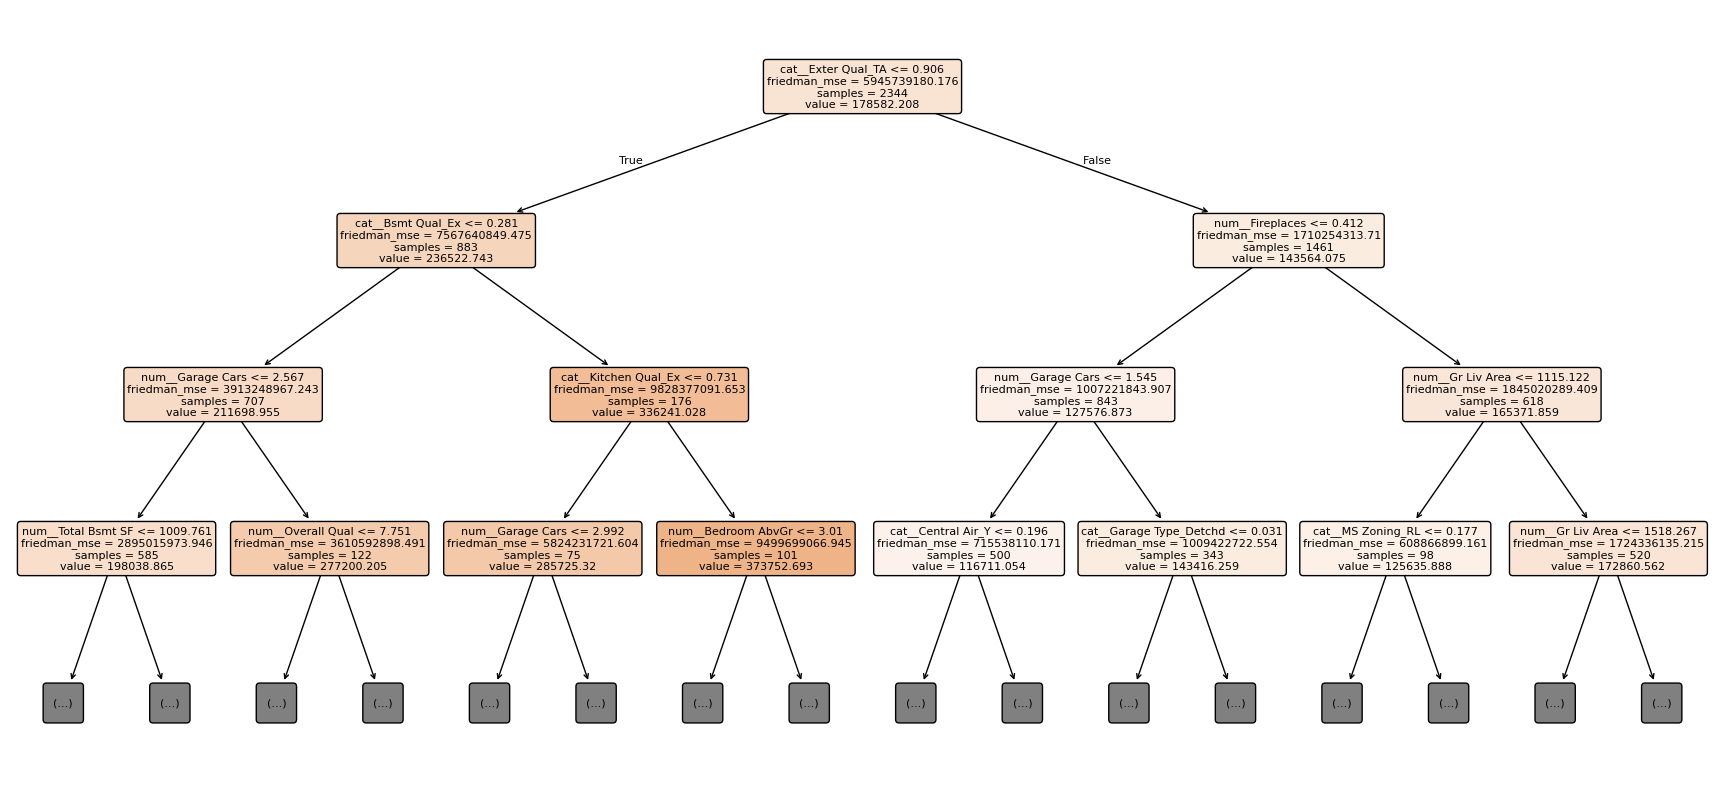

In [26]:
# Visualize the first three levels of the tree
plt.figure(figsize=(22, 10))

plot_tree(
    tree,
    feature_names=(
        decision_tree_regressor_search
        .best_estimator_
        .named_steps["preprocessor"]
        .get_feature_names_out()
    ),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.show()

# 3. Attributes and Hyperparameters

Decision Trees learn a set of decision rules from the training data. These rules determine how observations are recursively partitioned until a stopping criterion is reached.

---

### Model Attributes

The following attributes are learned automatically during training.

#### 1. tree_
Stores the complete tree structure learned during training. \
It contains information such as

- Node structure
- Split features
- Split thresholds
- Child nodes
- Impurity values

#### 2. feature_importances_
Represents the relative importance of each feature based on the total reduction in impurity contributed by that feature.

Properties

- Values lie between 0 and 1.
- Sum of all feature importances equals 1.

Higher values indicate greater influence on the prediction.

#### 3. n_features_in_
Stores the number of features used during training.

#### 4. feature_names_in_
Available when training with a Pandas DataFrame. \
Stores the names of the input features.

#### 5. classes_ (Classification)
Stores the unique target classes learned during training.

#### 6. n_classes_ (Classification)
Stores the number of target classes.

#### 7. n_outputs_
Number of target variables. \
Usually 1 for single-output problems.

---

### Hyperparameters

#### 1. criterion
*Classification* \
Default: gini \
Available Values: gini, entropy, log_loss

*Regression* \
Default: squared_error \
Available Values: squared_error, friedman_mse, absolute_error, poisson \
Determines how the quality of a split is measured.

#### 2. splitter
Default: best \
Available Values: best, random \
Controls how candidate splits are selected.
- best evaluates all possible splits.
- random randomly selects candidate splits before choosing the best among them.

#### 3. max_depth
Default: None \
Maximum depth of the tree. \
One of the most important hyperparameters to tune.

| Small Depth | Large Depth |
|--------------|-------------|
| Higher Bias | Lower Bias |
| Lower Variance | Higher Variance |
| Underfitting | Overfitting |

#### 4. min_samples_split
Default: 2 \
Minimum number of samples required to split a node. \
Increasing this value
- Produces simpler trees.
- Reduces overfitting.

#### 5. min_samples_leaf
Default: 1 \
Minimum number of samples required in each leaf node.
Increasing this value
- Produces smoother decision boundaries.
- Improves generalization, reduces overfitting.

#### 6. max_features
Default: None \
Available Values: None, sqrt, log2, Integer, Float \
Maximum number of features considered while searching for the best split. 
- Usually tuned for ensemble methods, but can also improve individual trees.
- Restricting the feature pool at each split forces the tree to look at different paths
- Prevents it from relying too heavily on a few highly dominant features
- Speeds up training

#### 7. max_leaf_nodes
Default: None \
Limits the maximum number of terminal nodes.
- Tells the algorithm to grow an unlimited number of leaf nodes until all leaves are pure or contain fewer samples than specified by min_samples_split.
- Useful for controlling tree complexity.
- Setting this value too low creates simpler, underfit trees
- Setting this value too high creates complex, overfit trees 

#### 8. min_impurity_decrease
Default: 0 \
A split is performed only if it decreases impurity by at least this amount. \
Higher values produce smaller trees.

#### 9. ccp_alpha
Default: 0 \
Cost Complexity Pruning parameter.
- Higher values remove more branches after the tree has been grown.
- Smaller values retain more branches
- One of the most effective techniques for reducing overfitting.

#### 10. random_state
Ensures reproducibility when randomness is involved. \
Always specify a fixed value.

---

### Hyperparameters to Tune

| Hyperparameter | Importance |
|----------------|------------|
| max_depth | ★★★★★ |
| min_samples_split | ★★★★★ |
| min_samples_leaf | ★★★★★ |
| ccp_alpha | ★★★★★ |
| criterion | ★★★★☆ |
| max_features | ★★★☆☆ |
| max_leaf_nodes | ★★★☆☆ |
| splitter | ★★☆☆☆ |


## Parameter Interactions

- Increasing max_depth generally requires increasing min_samples_leaf, else trees overfit
- Restricting max_features increases randomness and may improve generalization.
- A combination of max_depth, min_samples_split and min_samples_leaf provides effective pre-pruning.


## Key Takeaways

- Decision Trees learn decision rules rather than mathematical coefficients.
- Tree complexity is primarily controlled through depth and minimum sample constraints.
- Overfitting can be reduced using both pre-pruning and post-pruning techniques.
- Cost Complexity Pruning (`ccp_alpha`) is one of the most effective methods for improving generalization.

# 4. Data Requirements

Decision Trees are relatively robust to different data characteristics and require considerably less preprocessing than many other machine learning algorithms. However, certain data properties still influence model performance.

### Feature Scaling
Decision Trees split observations based on feature thresholds rather than distance calculations. \
Changing the scale of a feature does not alter the order of observations and therefore does not affect the split. \
Feature scaling is unnecessary unless the Decision Tree is part of a larger pipeline with algorithms that require scaling.

### Outliers
Decision Trees partition the data based on thresholds rather than minimizing distances or squared errors. \
Outliers generally do not require treatment unless they are data errors.

### Missing Values
Not supported directly in Scikit-learn. \
Use Imputer within the preprocessing pipeline.

### Categorical Features
Requires numerical input in Scikit-learn.

### High-Dimensional Data
Decision Trees can perform feature selection automatically by ignoring irrelevant features. \
However, extremely high-dimensional datasets may still lead to overfitting.

### Class Imbalance (Classification)
The algorithm tends to favour the majority class. \
Treat class imbalance with suitable methods.

### Feature Selection
Decision Trees automatically identify informative features while constructing the tree. \
However, removing highly irrelevant variables may improve generalization.

### Dimensionality Reduction
Generally Not Required
Decision Trees naturally perform implicit feature selection.

### Multicollinearity
Decision Trees split on only one feature at a time and do not estimate regression coefficients. Consequently, multicollinearity does not lead to unstable parameter estimates or inflated variances. \
However, when multiple highly correlated features are available, the tree may arbitrarily choose one feature over another for a split. As a result, feature importance may be distributed inconsistently across correlated predictors, making interpretation less reliable. \
Multicollinearity generally does not reduce the predictive performance of Decision Trees. It mainly affects the interpretation of feature importance rather than the model's predictive accuracy.

# 5. Summary

### Advantages

- Simple to understand and interpret.
- Supports both classification and regression tasks.
- Naturally models non-linear relationships and feature interactions.
- Requires minimal data preprocessing.
- Does not require feature scaling.
- Relatively robust to outliers.
- Performs automatic feature selection through recursive splitting.
- Provides inbuilt feature importance scores.
- Can handle both numerical and categorical features (after encoding in Scikit-learn).
- Easy to visualize and explain to non-technical stakeholders.


### Limitations

- Highly prone to overfitting if left unconstrained.
- Small changes in the training data can produce very different trees.
- Sensitive to noisy datasets.
- Can create biased trees when classes are highly imbalanced.
- Greedy splitting does not guarantee the globally optimal tree.
- Individual Decision Trees generally perform worse than ensemble methods such as Random Forests or Gradient Boosting.


### When to Use

Decision Trees are a good choice when

- Model interpretability is important.
- The relationship between features and the target is non-linear.
- Minimal preprocessing is preferred.
- Feature importance needs to be identified.
- Quick baseline models are required.
- Both numerical and categorical variables are present.


### When Not to Use

Decision Trees may not be the best choice when

- Maximum predictive accuracy is required.
- The dataset contains significant noise.
- The training data is very small.
- Stable predictions are required.


### Key Takeaways

- Decision Trees recursively partition the feature space to make predictions.
- They require minimal preprocessing and naturally model complex, non-linear relationships.
- Tree depth and pruning play a critical role in controlling overfitting.
- Built-in feature importance helps identify influential predictors.
- Although highly interpretable, individual Decision Trees are often outperformed by ensemble methods in terms of predictive accuracy.